##**Asosiasi Data & Sistem Rekomendasi Dasar**

**Step 1: Generate & Eksplorasi Dataset Transaksi**

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')

np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Contoh transaksi:', transaksi[:3])
print('Jumlah transaksi:', len(transaksi))

Contoh transaksi: [[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]
Jumlah transaksi: 50


In [3]:
# Mengubah Menjadi DataFrame

df_transaksi = pd.DataFrame({

    "ID_Transaksi": range(1,51),

    "Daftar_Item": [
        ", ".join(x)
        for x in transaksi
    ]
})

df_transaksi.head()

,ID_Transaksi,Daftar_Item
0,1,"Keju, Roti, Mentega, Kopi, Selai"
1,2,"Roti, Kopi, Teh, Selai, Mentega"
2,3,"Kopi, Susu, Teh"
3,4,"Selai, Keju, Telur, Teh"
4,5,"Mentega, Susu, Gula, Keju"


In [4]:
from collections import Counter

# Menghitung Frekuensi Produk

counter = Counter()
for trx in transaksi:
    counter.update(trx)

frekuensi = pd.DataFrame(
    counter.items(),
    columns=[
        "Produk",
        "Frekuensi"
    ]
)

frekuensi = frekuensi.sort_values(
    by="Frekuensi",
    ascending=False
)

frekuensi

,Produk,Frekuensi
4,Selai,26
5,Teh,23
2,Mentega,21
7,Telur,18
0,Keju,17
1,Roti,16
3,Kopi,16
6,Susu,16
8,Gula,16
9,Sereal,9


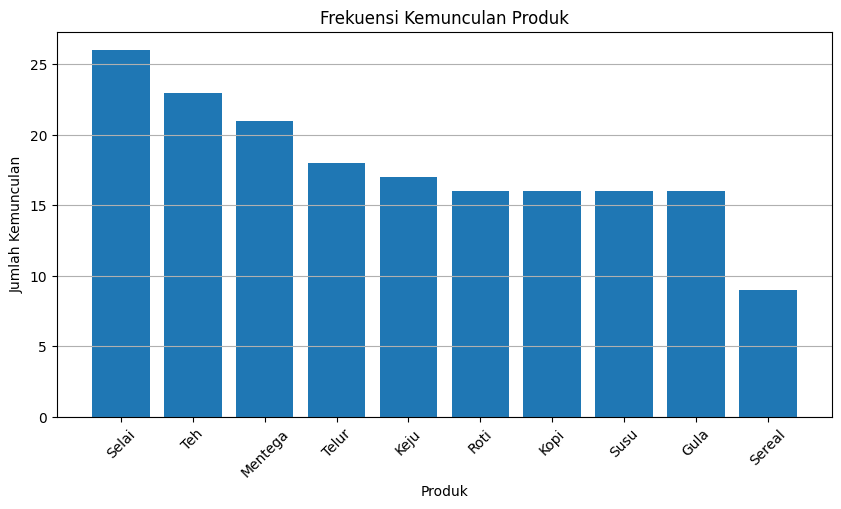

In [5]:
plt.figure(figsize=(10,5))
plt.bar(
    frekuensi["Produk"],
    frekuensi["Frekuensi"]
)

plt.title("Frekuensi Kemunculan Produk")
plt.xlabel("Produk")
plt.ylabel("Jumlah Kemunculan")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [6]:
print(
    "Produk paling sering muncul:",
    frekuensi.iloc[0]["Produk"]
)

print(
    "Frekuensi:",
    frekuensi.iloc[0]["Frekuensi"]
)

Produk paling sering muncul: Selai
Frekuensi: 26


**Step 2: One-Hot Encoding Transaksi**

In [7]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(te_ary, columns=te.columns_)

print(df.head())

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


**Step 3: Cari Frequent Itemset dengan Apriori**

In [20]:
import warnings
warnings.filterwarnings("ignore")

from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.1, 0.2]:
    freq = apriori(
        df,
        min_support=ms,
        use_colnames=True
    )

    print(f"min_support = {ms} : {len(freq)} itemset ditemukan")

min_support = 0.05 : 74 itemset ditemukan
min_support = 0.1 : 44 itemset ditemukan
min_support = 0.2 : 13 itemset ditemukan


In [22]:
freq_items = apriori(
    df,
    min_support=0.1,
    use_colnames=True
)

freq_items = freq_items.sort_values(
    by="support",
    ascending=False
)

freq_items["Support (%)"] = (
    freq_items["support"] * 100
).round(2)

freq_items.head(10)

,support,itemsets,Support (%)
5,0.52,(Selai),52.0
8,0.46,(Teh),46.0
3,0.42,(Mentega),42.0
9,0.36,(Telur),36.0
1,0.34,(Keju),34.0
0,0.32,(Gula),32.0
2,0.32,(Kopi),32.0
4,0.32,(Roti),32.0
7,0.32,(Susu),32.0
36,0.24,"(Selai, Teh)",24.0


**Step 4: Bentuk & Saring Aturan Asosiasi**

In [23]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.6
)

print("Jumlah aturan :", len(rules))
rules.head()

Jumlah aturan : 10


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Roti),(Selai),0.32,0.52,0.22,0.687500,1.322115,1.0,0.0536,1.536,0.358289,0.354839,0.348958,0.555288
1,(Gula),(Selai),0.32,0.52,0.20,0.625000,1.201923,1.0,0.0336,1.280,0.247059,0.312500,0.218750,0.504808
2,(Sereal),(Mentega),0.18,0.42,0.14,0.777778,1.851852,1.0,0.0644,2.610,0.560976,0.304348,0.616858,0.555556
3,"(Keju, Teh)",(Telur),0.14,0.36,0.12,0.857143,2.380952,1.0,0.0696,4.480,0.674419,0.315789,0.776786,0.595238
4,"(Keju, Telur)",(Teh),0.16,0.46,0.12,0.750000,1.630435,1.0,0.0464,2.160,0.460317,0.240000,0.537037,0.505435


In [24]:
rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

rules.head(10)

rules = rules.sort_values(
    by="confidence",
    ascending=False
)

rules.head(10)

rules["Support (%)"] = (
    rules["support"]*100
).round(2)

rules["Confidence (%)"] = (
    rules["confidence"]*100
).round(2)

rules.head(10)

best_rule = rules.iloc[0]

print("Antecedent :", best_rule["antecedents"])
print("Consequent :", best_rule["consequents"])
print("Support :", round(best_rule["support"],3))
print("Confidence :", round(best_rule["confidence"],3))
print("Lift :", round(best_rule["lift"],3))

Antecedent : frozenset({np.str_('Roti'), np.str_('Gula')})
Consequent : frozenset({'Selai'})
Support : 0.1
Confidence : 1.0
Lift : 1.923


In [25]:
for i, row in rules.iterrows():
    print("="*50)
    print(f"Rule {i+1}")
    print(f"{set(row['antecedents'])} --> {set(row['consequents'])}")
    print(f"Support    : {row['support']:.2f}")
    print(f"Confidence : {row['confidence']:.2f}")
    print(f"Lift       : {row['lift']:.2f}")

Rule 7
{np.str_('Roti'), np.str_('Gula')} --> {'Selai'}
Support    : 0.10
Confidence : 1.00
Lift       : 1.92
Rule 4
{np.str_('Keju'), np.str_('Teh')} --> {np.str_('Telur')}
Support    : 0.12
Confidence : 0.86
Lift       : 2.38
Rule 3
{np.str_('Sereal')} --> {np.str_('Mentega')}
Support    : 0.14
Confidence : 0.78
Lift       : 1.85
Rule 5
{np.str_('Keju'), np.str_('Telur')} --> {np.str_('Teh')}
Support    : 0.12
Confidence : 0.75
Lift       : 1.63
Rule 9
{np.str_('Kopi'), np.str_('Mentega')} --> {'Selai'}
Support    : 0.10
Confidence : 0.71
Lift       : 1.37
Rule 8
{np.str_('Kopi'), 'Selai'} --> {np.str_('Mentega')}
Support    : 0.10
Confidence : 0.71
Lift       : 1.70
Rule 1
{np.str_('Roti')} --> {'Selai'}
Support    : 0.22
Confidence : 0.69
Lift       : 1.32
Rule 2
{np.str_('Gula')} --> {'Selai'}
Support    : 0.20
Confidence : 0.62
Lift       : 1.20
Rule 10
{'Selai', np.str_('Mentega')} --> {np.str_('Kopi')}
Support    : 0.10
Confidence : 0.62
Lift       : 1.95
Rule 6
{np.str_('Telur

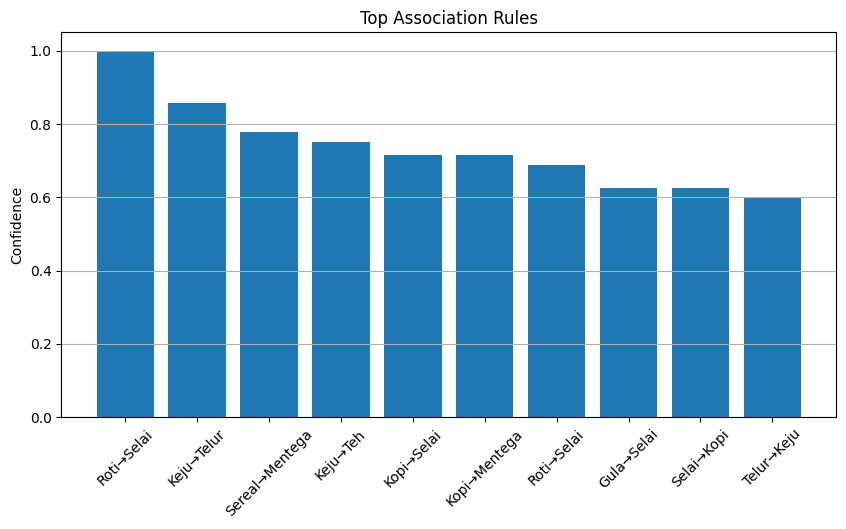

In [26]:
top_rules = rules.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top_rules)),
    top_rules["confidence"]
)

plt.xticks(
    range(len(top_rules)),
    [
        f"{list(a)[0]}→{list(c)[0]}"
        for a,c in zip(
            top_rules["antecedents"],
            top_rules["consequents"]
        )
    ],
    rotation=45
)

plt.ylabel("Confidence")
plt.title("Top Association Rules")
plt.grid(axis="y")
plt.show()

Aturan mana yang paling kuat (Lift tertinggi)?

In [27]:
rules.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,support,confidence,lift,Support (%),Confidence (%)
3,"(Keju, Teh)",(Telur),0.12,0.857143,2.380952,12.0,85.71
9,"(Selai, Mentega)",(Kopi),0.10,0.625000,1.953125,10.0,62.50
6,"(Roti, Gula)",(Selai),0.10,1.000000,1.923077,10.0,100.00
2,(Sereal),(Mentega),0.14,0.777778,1.851852,14.0,77.78
5,"(Telur, Teh)",(Keju),0.12,0.600000,1.764706,12.0,60.00
7,"(Kopi, Selai)",(Mentega),0.10,0.714286,1.700680,10.0,71.43
4,"(Keju, Telur)",(Teh),0.12,0.750000,1.630435,12.0,75.00
8,"(Kopi, Mentega)",(Selai),0.10,0.714286,1.373626,10.0,71.43
0,(Roti),(Selai),0.22,0.687500,1.322115,22.0,68.75
1,(Gula),(Selai),0.20,0.625000,1.201923,20.0,62.50


- Support: 12% berarti sebanyak 12% dari seluruh transaksi mengandung kombinasi Teh, Keju, dan Telur.

- Confidence: 85,71% berarti 85,71% transaksi yang berisi Teh dan Keju juga mengandung Telur.

- Lift: 2,38 berarti pelanggan yang membeli Teh dan Keju memiliki kemungkinan sekitar 2,38 kali lebih besar untuk membeli Telur dibandingkan jika pembelian Telur terjadi secara acak. Nilai lift yang lebih besar dari 1 menunjukkan hubungan asosiasi yang kuat.

Apakah masuk akal secara bisnis?

Aturan ini masih masuk akal secara bisnis karena teh, keju, dan telur merupakan produk yang dapat dikonsumsi bersamaan sebagai menu sarapan atau makanan ringan. Selain itu, aturan {Roti} → {Selai} juga memiliki hubungan yang logis karena kedua produk saling melengkapi, meskipun nilai lift-nya lebih rendah dibandingkan aturan pertama.

**Step 5: Rekomender Sederhana dengan Content-Based Filtering**

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

produk = pd.DataFrame({
    "Produk": [
        "Roti",
        "Selai",
        "Susu",
        "Keju",
        "Mentega",
        "Kopi",
        "Teh",
        "Sereal",
        "Telur",
        "Gula"
    ],
    "Kategori": [
        "Makanan Sarapan Roti",
        "Makanan Olesan Sarapan",
        "Minuman Susu",
        "Produk Olahan Susu",
        "Makanan Olesan Roti",
        "Minuman Panas",
        "Minuman Panas",
        "Makanan Sarapan",
        "Protein Sarapan",
        "Pemanis Minuman"
    ]
})

produk

,Produk,Kategori
0,Roti,Makanan Sarapan Roti
1,Selai,Makanan Olesan Sarapan
2,Susu,Minuman Susu
3,Keju,Produk Olahan Susu
4,Mentega,Makanan Olesan Roti
5,Kopi,Minuman Panas
6,Teh,Minuman Panas
7,Sereal,Makanan Sarapan
8,Telur,Protein Sarapan
9,Gula,Pemanis Minuman


In [29]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(
    produk["Kategori"]
)

cosine_sim = cosine_similarity(tfidf_matrix)
cosine_sim
similarity_df = pd.DataFrame(
    cosine_sim,
    index=produk["Produk"],
    columns=produk["Produk"]
)

similarity_df
def rekomendasi(nama_produk, top_n=3):
    skor = similarity_df[nama_produk]
    rekom = skor.sort_values(
        ascending=False
    )[1:top_n+1]
    return rekom

hasil = rekomendasi("Roti").reset_index()
hasil.columns = [
    "Produk Rekomendasi",
    "Similarity"
]
hasil

,Produk Rekomendasi,Similarity
0,Sereal,0.739947
1,Mentega,0.668921
2,Selai,0.547521


**Step 6: Bandingkan Kedua Pendekatan**

In [30]:
print("=== Association Rule ===")
print("Jika pelanggan membeli: Roti")
print("Maka direkomendasikan: Selai")
print("Confidence : 68.75%")
print("Lift : 1.32")

print("\n")

print("=== Content-Based Filtering ===")
hasil = rekomendasi("Roti")
print(hasil)

=== Association Rule ===
Jika pelanggan membeli: Roti
Maka direkomendasikan: Selai
Confidence : 68.75%
Lift : 1.32


=== Content-Based Filtering ===
Produk
Sereal     0.739947
Mentega    0.668921
Selai      0.547521
Name: Roti, dtype: float64


In [31]:
perbandingan = pd.DataFrame({
    "Aspek": [
        "Dasar Rekomendasi",
        "Sumber Data",
        "Kelebihan",
        "Kekurangan"
    ],
    "Association Rule": [
        "Pola pembelian bersama",
        "Riwayat transaksi",
        "Menemukan kebiasaan pelanggan",
        "Perlu banyak data transaksi"
    ],
    "Content-Based": [
        "Kemiripan karakteristik produk",
        "Informasi atribut produk",
        "Tidak membutuhkan riwayat transaksi pengguna lain",
        "Bergantung pada kualitas atribut produk"
    ]
})

perbandingan

,Aspek,Association Rule,Content-Based
0,Dasar Rekomendasi,Pola pembelian bersama,Kemiripan karakteristik produk
1,Sumber Data,Riwayat transaksi,Informasi atribut produk
2,Kelebihan,Menemukan kebiasaan pelanggan,Tidak membutuhkan riwayat transaksi pengguna lain
3,Kekurangan,Perlu banyak data transaksi,Bergantung pada kualitas atribut produk


**Apakah kedua pendekatan menghasilkan rekomendasi yang konsisten?**

Secara umum, kedua metode menghasilkan rekomendasi yang sejalan meskipun menggunakan prinsip kerja yang berbeda.

Pada **Association Rule Mining (Apriori)**, rekomendasi diperoleh dari pola pembelian yang terbentuk berdasarkan riwayat transaksi pelanggan. Sebagai contoh, aturan *Roti → Selai* menunjukkan bahwa pelanggan yang membeli roti memiliki kecenderungan untuk juga membeli selai, sehingga kedua produk tersebut direkomendasikan secara bersamaan.

Di sisi lain, **Content-Based Filtering** memberikan rekomendasi dengan mempertimbangkan tingkat kemiripan atribut atau karakteristik antarproduk. Misalnya, produk seperti roti, selai, dan mentega termasuk dalam kategori makanan sarapan sehingga dianggap memiliki kesamaan dan layak direkomendasikan sebagai produk terkait.

Meskipun pendekatan yang digunakan berbeda, keduanya tetap menghasilkan rekomendasi yang masuk akal karena sama-sama menghubungkan produk yang saling berkaitan, baik berdasarkan kebiasaan pembelian pelanggan maupun kesamaan karakteristik produk. Hal ini menunjukkan bahwa kedua metode dapat saling melengkapi dalam membangun sistem rekomendasi yang lebih efektif.

**Kapan sebaiknya menggunakan salah satu metode atau menggabungkan keduanya (Hybrid)?**

**Association Rule Mining** lebih sesuai diterapkan ketika perusahaan telah memiliki data transaksi dalam jumlah besar. Metode ini sangat efektif untuk mengidentifikasi pola pembelian pelanggan yang dapat dimanfaatkan dalam strategi *cross-selling*, *bundling* produk, maupun penataan produk di dalam toko.

Sementara itu, **Content-Based Filtering** lebih tepat digunakan apabila informasi mengenai atribut atau karakteristik produk sudah tersedia secara lengkap, tetapi data transaksi masih terbatas sehingga belum cukup untuk menemukan pola pembelian pelanggan. Metode ini juga bermanfaat untuk merekomendasikan produk yang memiliki karakteristik serupa.

Apabila perusahaan memiliki data transaksi sekaligus informasi atribut produk yang memadai, maka **Hybrid Recommender System** menjadi pilihan yang paling optimal. Dengan mengombinasikan Association Rule Mining dan Content-Based Filtering, sistem mampu menghasilkan rekomendasi yang lebih akurat karena mempertimbangkan pola perilaku pelanggan serta kemiripan karakteristik produk. Selain meningkatkan kualitas rekomendasi, pendekatan hybrid juga dapat mengurangi kelemahan yang dimiliki masing-masing metode apabila digunakan secara terpisah.
